,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


Shape: (3282, 6)

Columns: ['Sales Person', 'Country', 'Product', 'Date', 'Amount', 'Boxes Shipped']

Dtypes:
 Sales Person       str
Country            str
Product            str
Date               str
Amount             str
Boxes Shipped    int64
dtype: object

Missing values:
 Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Duplicate rows: 0

After conversion missing values:
 Sales Person        0
Country             0
Product             0
Date             1992
Amount              0
Boxes Shipped       0
dtype: int64

Updated dtypes:
 Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3282,3282,3282,1290,3282.000000,3282.000000
unique,25,6,22,NaN,NaN,NaN
top,Kelci Walkden,Australia,50% Dark Bites,NaN,NaN,NaN
freq,162,615,180,NaN,NaN,NaN
mean,NaN,NaN,NaN,2023-06-25 18:39:37.674418,6030.338775,164.666971
min,NaN,NaN,NaN,2022-01-02 00:00:00,7.000000,1.000000
25%,NaN,NaN,NaN,2022-10-03 00:00:00,2521.495000,71.000000
50%,NaN,NaN,NaN,2023-07-02 00:00:00,5225.500000,137.000000
75%,NaN,NaN,NaN,2024-04-03 00:00:00,8556.842500,232.000000
max,NaN,NaN,NaN,2024-12-08 00:00:00,26170.950000,778.000000


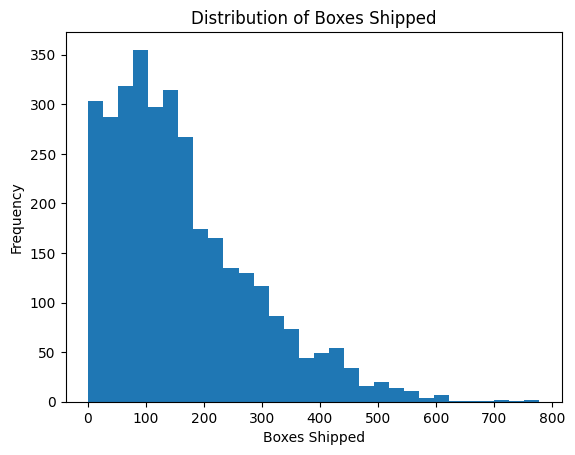

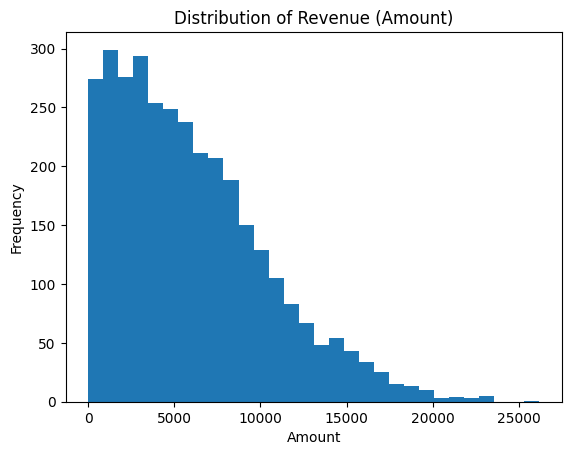

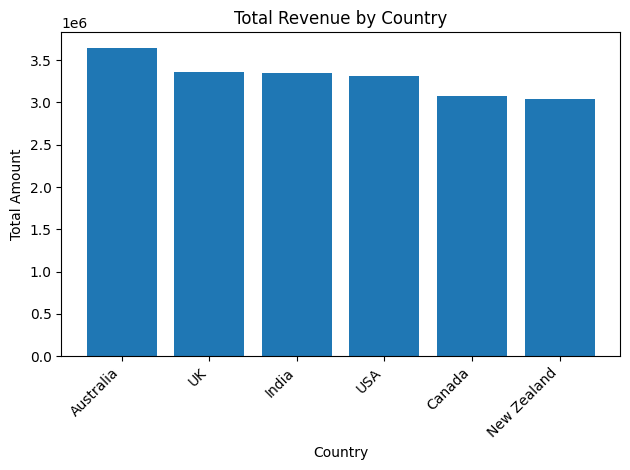

,Total Amount
Country,
Australia,3646444.35
UK,3365388.90
India,3343730.83
USA,3313858.09
Canada,3078495.65
New Zealand,3043654.04


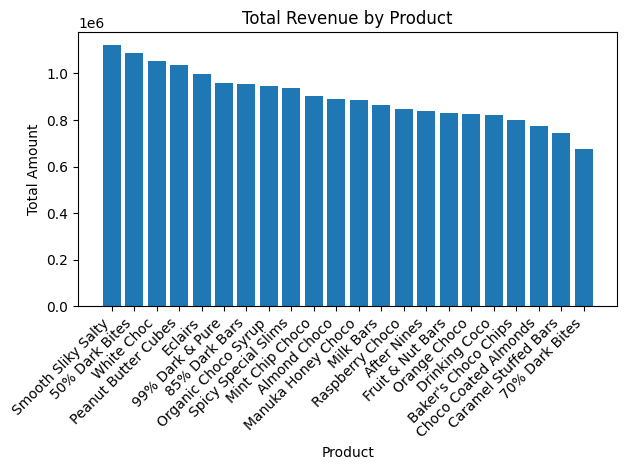

,Total Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


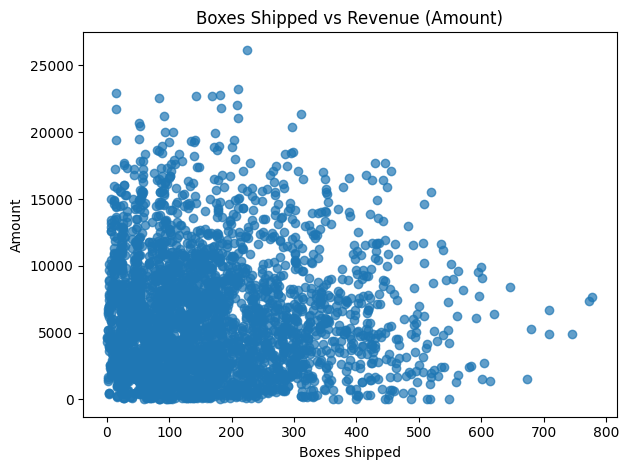

,Amount,Boxes Shipped
Amount,1.000000,-0.013154
Boxes Shipped,-0.013154,1.000000


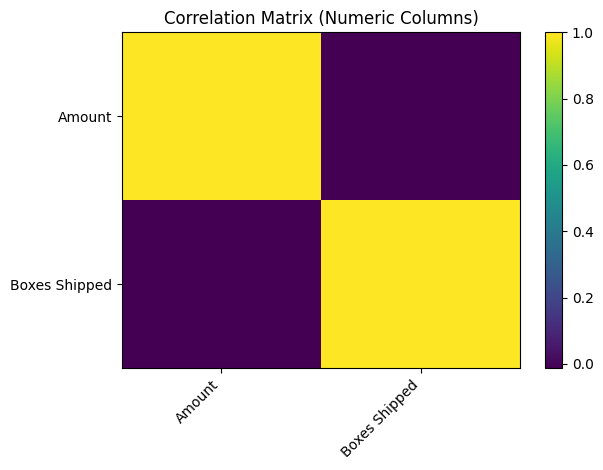

,Total Amount
Month,
2022-01,168728.00
2022-02,146097.00
2022-03,192059.00
2022-04,312487.00
2022-05,216132.00
2022-06,113470.00
2022-07,271747.00
2022-08,173250.00
2022-09,144291.00


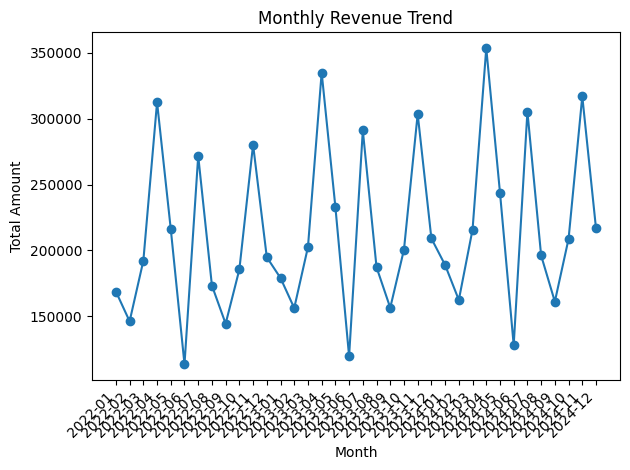

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("Chocolate_Sales.csv")
display(df.head())

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

if "Amount" in df.columns:
    df["Amount"] = (
        df["Amount"].astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
    )
    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print("\nAfter conversion missing values:\n", df.isnull().sum())
print("\nUpdated dtypes:\n", df.dtypes)

display(df.describe(include="all"))

if "Boxes Shipped" in df.columns:
    plt.figure()
    plt.hist(df["Boxes Shipped"].dropna(), bins=30)
    plt.title("Distribution of Boxes Shipped")
    plt.xlabel("Boxes Shipped")
    plt.ylabel("Frequency")
    plt.show()

if "Amount" in df.columns:
    plt.figure()
    plt.hist(df["Amount"].dropna(), bins=30)
    plt.title("Distribution of Revenue (Amount)")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    plt.show()

if "Country" in df.columns and "Amount" in df.columns:
    country_sales = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)
    plt.figure()
    plt.bar(country_sales.index.astype(str), country_sales.values)
    plt.title("Total Revenue by Country")
    plt.xlabel("Country")
    plt.ylabel("Total Amount")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(country_sales.to_frame("Total Amount"))

if "Product" in df.columns and "Amount" in df.columns:
    product_sales = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)
    plt.figure()
    plt.bar(product_sales.index.astype(str), product_sales.values)
    plt.title("Total Revenue by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Amount")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(product_sales.to_frame("Total Amount"))

if "Boxes Shipped" in df.columns and "Amount" in df.columns:
    plt.figure()
    plt.scatter(df["Boxes Shipped"], df["Amount"], alpha=0.7)
    plt.title("Boxes Shipped vs Revenue (Amount)")
    plt.xlabel("Boxes Shipped")
    plt.ylabel("Amount")
    plt.tight_layout()
    plt.show()

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)
display(corr)

plt.figure()
plt.imshow(corr, aspect="auto")
plt.title("Correlation Matrix (Numeric Columns)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

if "Date" in df.columns and "Amount" in df.columns:
    df["Month"] = df["Date"].dt.to_period("M").astype(str)
    monthly_sales = df.groupby("Month")["Amount"].sum()
    display(monthly_sales.to_frame("Total Amount"))

    plt.figure()
    plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
    plt.title("Monthly Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Amount")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
